In [107]:
import jax.numpy as jnp
from jax.scipy.linalg import solve, lu
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator 
import numpy as np  

# 4.3 Crank-Nicolson-Method

In [108]:
# ---- Parameters ----
v_max = 6
m = 6
x_max = 3
x_min = -3

option_type = "put"  # "put" or "call"
T = 1
K = 40

r = 0.04
delta = 0.02
sigma = 0.4

In [109]:
# ---- Grid setup ----
delta_x = (x_max - x_min) / m

x = jnp.linspace(x_min, x_max, m + 1)
x_interior = x[1:-1]  

tau_max = 0.5 * sigma**2 * T
delta_tau = tau_max / v_max
lamb = delta_tau / (delta_x ** 2)

#delta_tau < (delta_x**2) / 2


In [110]:
# ---- Initial condition w(x, 0) ----
q_delta = 2 * (r - delta) / (sigma ** 2)

init = jnp.exp((x_interior/2)*(q_delta+1))  
init -= jnp.exp((x_interior/2)*(q_delta-1))

if option_type == "put":
    init = -init

w = jnp.zeros((m - 1, v_max + 1))
w = w.at[:,0].set(jnp.maximum(init, 0))

In [111]:
# ---- Matrices A and B ----

diag_mainA = (1 + 2 * lamb) * jnp.ones(m - 1)
diag_mainB = (1 - 2 * lamb) * jnp.ones(m - 1)

diag_off = lamb / 2 * jnp.ones(m - 2)

A = jnp.diag(diag_mainA) - jnp.diag(diag_off, 1) - jnp.diag(diag_off, -1)
B = jnp.diag(diag_mainB) + jnp.diag(diag_off, 1) + jnp.diag(diag_off, -1)

In [112]:
# ---- Time stepping - Algorithm 4.5 ----
def step_fn(w_nu):
    c = jnp.matmul(B, w[:, w_nu])
    return solve(A, c)

for nu in range(0, v_max):
    result = step_fn(nu)
    w = w.at[:, nu+1].set(step_fn(nu))

In [113]:
# ---- Undo transformation to pass from w(x,tau) to v(x, tau) - equation (4.3)----
tau = jnp.linspace(0, tau_max, v_max + 1)
q = 2 * r / sigma**2

factor = jnp.exp(
    -0.5 * (q_delta - 1) * x_interior[:, None] -
    (0.25 * (q_delta - 1)**2 + q) * tau[None, :]
)
v = K * factor * w

In [114]:
# ---- Interpolation and change of variables from v(x, tau) to V(S, t) ----
v_np = np.array(v)
x_np = np.array(x_interior)
tau_np = np.array(tau)
v_interp = RegularGridInterpolator((x_np, tau_np), v_np, bounds_error=False, fill_value=None)

def V(S, t):
    x_val = np.log(S/K)
    tau_val = 0.5 * sigma**2 * (T - t)
    return v_interp([x_val, tau_val])

# Visualization

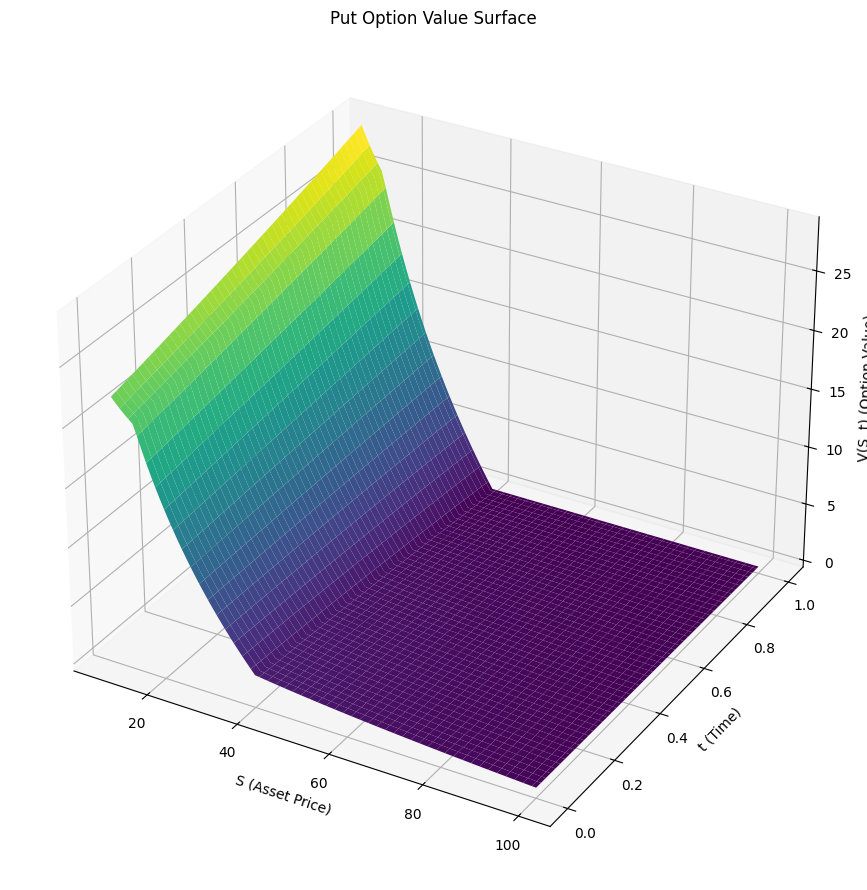

In [115]:
S_vals = np.linspace(10, 100, 100)
t_vals = np.linspace(0, T, 100)
S_grid, t_grid = np.meshgrid(S_vals, t_vals)
V_func = np.vectorize(V)
V_grid = V_func(S_grid, t_grid)

fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S_grid, t_grid, V_grid, cmap='viridis')
ax.set_xlabel('S (Asset Price)')
ax.set_ylabel('t (Time)')
ax.set_zlabel('V(S, t) (Option Value)')
ax.set_title(f"{option_type.capitalize()} Option Value Surface")
plt.tight_layout()
plt.show()

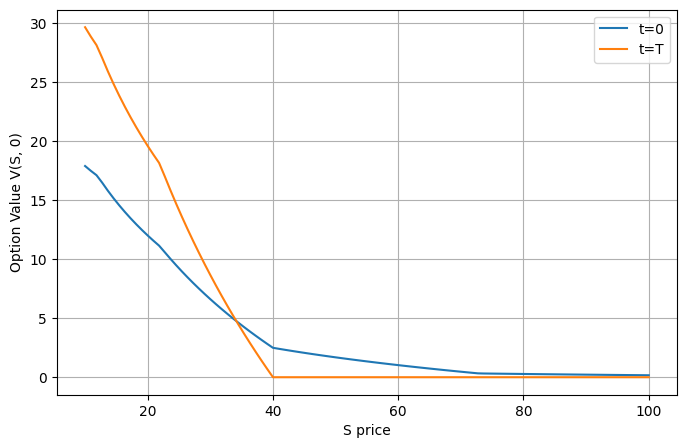

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(S_vals, V_grid[0,:], label="t=0")
plt.plot(S_vals, V_grid[-1,:], label="t=T")
plt.xlabel("S price")
plt.ylabel("Option Value V(S, 0)")
plt.legend()
plt.grid(True)
plt.show()

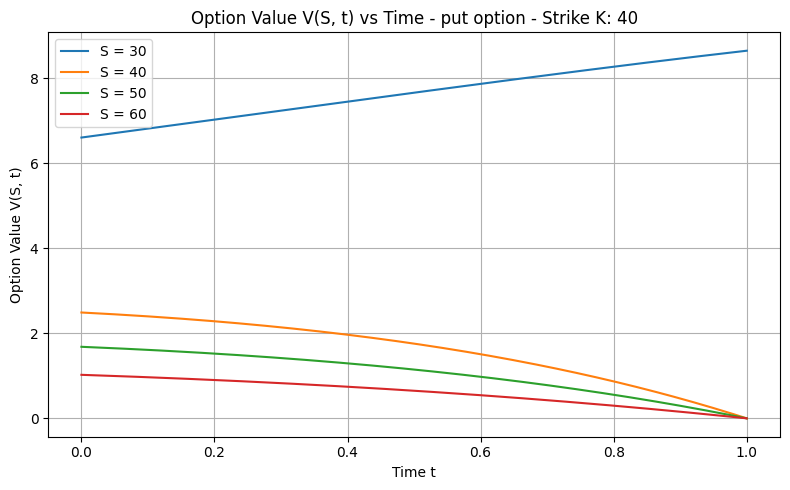

In [ ]:
def plot_V_over_time(S_list):
    t_vals = np.linspace(0, T, 200)
    plt.figure(figsize=(8, 5))
    for S in S_list:
        values = [V(S, t) for t in t_vals]
        plt.plot(t_vals, values, label=f"S = {S}")
    plt.title(f"Option Value V(S, t) vs Time - {option_type} option - Strike K: {K}")
    plt.xlabel("Time t")
    plt.ylabel("Option Value V(S, t)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_V_over_time([30, 40, 50, 60])
